# Convolution Playground — Step-by-Step Visualizer

A small generalized toolkit that:

1. Takes **any** input matrix (an "image"), **any** convolutional kernel, any **stride**, and any **padding**.
2. Computes the convolution output.
3. **Animates** the sliding-window computation step by step (à la [deeplizard's CNN visualizer](https://deeplizard.com/resource/pavq7noze2)) — you see the receptive-field window slide across the (padded) input on the left, and the output matrix fill in cell-by-cell on the right.
4. Includes a helper to turn a **grayscale image into a matrix**.
5. Ends with a real example on the **MNIST** dataset using a simple **3×3 left-edge-detection kernel**.

> Change `padding`, `stride`, or the `kernel` anywhere below and re-run — everything is generalized.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from PIL import Image

plt.rcParams['animation.embed_limit'] = 50  # MB, room for longer animations

## 1. Core generalized functions

- `pad_matrix(matrix, padding, pad_value=0)` — zero-pads (or constant-pads) a 2D matrix on all sides.
- `compute_output_shape(input_shape, kernel_shape, stride, padding)` — standard CNN output-size formula:
  $$\text{out} = \left\lfloor \frac{H + 2P - K}{S} \right\rfloor + 1$$
- `convolve2d(matrix, kernel, stride=1, padding=0)` — performs the convolution (technically cross-correlation, as CNNs do) and **also records every intermediate step** (which window was used, what value it produced, and what the output looked like at that point) so we can animate it afterwards.

In [2]:
def pad_matrix(matrix, padding, pad_value=0):
    """Pad a 2D matrix with `padding` rows/cols of `pad_value` on every side."""
    matrix = np.asarray(matrix, dtype=float)
    if padding == 0:
        return matrix
    return np.pad(matrix, pad_width=padding, mode='constant', constant_values=pad_value)


def compute_output_shape(input_shape, kernel_shape, stride=1, padding=0):
    """Standard conv output-size formula: floor((H + 2P - K) / S) + 1, per dimension."""
    H, W = input_shape
    kH, kW = kernel_shape
    out_h = (H + 2 * padding - kH) // stride + 1
    out_w = (W + 2 * padding - kW) // stride + 1
    if out_h <= 0 or out_w <= 0:
        raise ValueError(
            f"Invalid configuration: kernel ({kH}x{kW}) does not fit on padded input "
            f"({H + 2*padding}x{W + 2*padding}) with stride {stride}."
        )
    return out_h, out_w


def convolve2d(matrix, kernel, stride=1, padding=0, pad_value=0):
    """
    Generalized 2D convolution (cross-correlation) with full step-by-step trace.

    Parameters
    ----------
    matrix   : 2D array-like, any size  -> the "image"
    kernel   : 2D array-like, any size  -> the convolutional filter
    stride   : int, step size of the sliding window
    padding  : int, zero-padding added on every side of the input
    pad_value: value used for padding (default 0)

    Returns
    -------
    output : np.ndarray, the final convolution result
    steps  : list of dicts, one per output cell, in the order they were computed.
             Each dict has: out_pos, patch_pos, patch, value, output_so_far
    padded : np.ndarray, the padded input actually used for the sliding window
    """
    matrix = np.asarray(matrix, dtype=float)
    kernel = np.asarray(kernel, dtype=float)
    padded = pad_matrix(matrix, padding, pad_value)
    kH, kW = kernel.shape
    out_h, out_w = compute_output_shape(matrix.shape, kernel.shape, stride, padding)

    output = np.zeros((out_h, out_w))
    output_display = np.full((out_h, out_w), np.nan)  # NaN = "not computed yet" (for animation)
    steps = []

    for i in range(out_h):
        for j in range(out_w):
            r0, c0 = i * stride, j * stride
            patch = padded[r0:r0 + kH, c0:c0 + kW]
            val = float(np.sum(patch * kernel))

            output[i, j] = val
            output_display[i, j] = val

            steps.append({
                'out_pos': (i, j),
                'patch_pos': (r0, c0),
                'patch': patch.copy(),
                'value': val,
                'output_so_far': output_display.copy(),
            })

    return output, steps, padded

### Quick sanity check

In [3]:
test_matrix = np.arange(25).reshape(5, 5)
test_kernel = np.array([[1, 0, -1],
                         [1, 0, -1],
                         [1, 0, -1]])

out, steps, padded = convolve2d(test_matrix, test_kernel, stride=1, padding=0)
print("Input:\n", test_matrix)
print("\nOutput:\n", out)
print("\nNumber of steps recorded:", len(steps))

Input:
 [[ 0  1  2  3  4]
 [ 5  6  7  8  9]
 [10 11 12 13 14]
 [15 16 17 18 19]
 [20 21 22 23 24]]

Output:
 [[-6. -6. -6.]
 [-6. -6. -6.]
 [-6. -6. -6.]]

Number of steps recorded: 9


## 2. Step-by-step animation

`animate_convolution(matrix, kernel, stride=1, padding=0, interval=600)` renders a two-panel animation:

- **Left panel** — the (padded) input, with a red box showing the current receptive field / sliding window.
- **Right panel** — the output matrix, filling in one cell at a time as its dot-product is computed. Cells not yet computed are left blank.

Works for *any* matrix/kernel/stride/padding combination — it's driven entirely by the `steps` trace from `convolve2d`.

In [4]:
def _draw_matrix(ax, mat, title, cmap, highlight=None, highlight_size=None, fmt='{:.0f}'):
    ax.clear()
    finite = mat[~np.isnan(mat)]
    if finite.size > 0:
        vmin, vmax = finite.min(), finite.max()
        if vmin == vmax:
            vmax = vmin + 1
    else:
        vmin, vmax = 0, 1

    display_mat = np.ma.masked_invalid(mat)
    cmap_obj = plt.get_cmap(cmap).copy()
    cmap_obj.set_bad(color='#e8e8e8')  # not-yet-computed cells
    ax.imshow(display_mat, cmap=cmap_obj, vmin=vmin, vmax=vmax)

    for (r, c), v in np.ndenumerate(mat):
        if not np.isnan(v):
            # pick readable text color
            norm = (v - vmin) / (vmax - vmin)
            color = 'white' if norm > 0.5 else 'black'
            ax.text(c, r, fmt.format(v), ha='center', va='center',
                     color=color, fontsize=9)

    if highlight is not None:
        r0, c0 = highlight
        h, w = highlight_size
        rect = patches.Rectangle((c0 - 0.5, r0 - 0.5), w, h,
                                   linewidth=3, edgecolor='red', facecolor='none')
        ax.add_patch(rect)

    ax.set_title(title, fontsize=11)
    ax.set_xticks([])
    ax.set_yticks([])


def animate_convolution(matrix, kernel, stride=1, padding=0, interval=600,
                          input_cmap='Blues', output_cmap='Greens', fmt='{:.0f}'):
    """
    Build and return a matplotlib FuncAnimation showing the convolution of
    `matrix` with `kernel` (given stride/padding) computed step by step.

    Display it in a notebook with: HTML(anim.to_jshtml())
    """
    matrix = np.asarray(matrix, dtype=float)
    kernel = np.asarray(kernel, dtype=float)
    output, steps, padded = convolve2d(matrix, kernel, stride, padding)
    kH, kW = kernel.shape

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5.5))
    fig.suptitle(f"Convolution — kernel {kH}x{kW}, stride={stride}, padding={padding}", fontsize=12)

    def update(frame):
        step = steps[frame]
        r0, c0 = step['patch_pos']
        io, jo = step['out_pos']

        _draw_matrix(ax1, padded,
                     f"Input (padded {padded.shape[0]}x{padded.shape[1]}) — window @ row {r0}, col {c0}",
                     cmap=input_cmap, highlight=(r0, c0), highlight_size=(kH, kW), fmt=fmt)

        _draw_matrix(ax2, step['output_so_far'],
                     f"Output {output.shape[0]}x{output.shape[1]} — computing cell ({io}, {jo}) = {step['value']:.2f}",
                     cmap=output_cmap, highlight=(io, jo), highlight_size=(1, 1), fmt=fmt)

        fig.tight_layout(rect=[0, 0, 1, 0.94])
        return ax1, ax2

    anim = FuncAnimation(fig, update, frames=len(steps), interval=interval, blit=False, repeat=True)
    plt.close(fig)  # prevent a static duplicate figure from also rendering
    return anim, output

## 3. Demo — small matrix + left-edge-detection kernel

A simple 3×3 **left-edge detection** kernel (a classic Sobel-style vertical-edge filter):

```
 1   0  -1
 1   0  -1
 1   0  -1
```

Try changing `stride` and `padding` below and re-running the cell — the animation adapts automatically.

In [5]:
left_edge_kernel = np.array([
    [1, 0, -1],
    [1, 0, -1],
    [1, 0, -1],
])

demo_matrix = np.array([
    [10, 10, 10, 0,  0,  0],
    [10, 10, 10, 0,  0,  0],
    [10, 10, 10, 0,  0,  0],
    [10, 10, 10, 0,  0,  0],
    [10, 10, 10, 0,  0,  0],
    [10, 10, 10, 0,  0,  0],
])

STRIDE = 1
PADDING = 0

anim, result = animate_convolution(demo_matrix, left_edge_kernel, stride=STRIDE, padding=PADDING, interval=500)
print("Final output:\n", result)
HTML(anim.to_jshtml())

Final output:
 [[ 0. 30. 30.  0.]
 [ 0. 30. 30.  0.]
 [ 0. 30. 30.  0.]
 [ 0. 30. 30.  0.]]


## 4. Grayscale image → matrix

Turns any image file (or an already-loaded PIL `Image`) into a 2D numpy matrix of pixel intensities (0–255), converting to grayscale first if needed. Optionally resize (handy for keeping animations fast on large photos).

In [6]:
def image_to_matrix(image, resize=None):
    """
    Convert a grayscale (or color, auto-converted) image into a 2D numpy matrix.

    Parameters
    ----------
    image  : str path to an image file, OR a PIL.Image.Image object, OR a numpy array
    resize : optional (width, height) tuple to resize before converting

    Returns
    -------
    np.ndarray of shape (H, W), dtype float, values 0-255
    """
    if isinstance(image, np.ndarray):
        img = Image.fromarray(image.astype('uint8'))
    elif isinstance(image, str):
        img = Image.open(image)
    else:
        img = image

    img = img.convert('L')  # grayscale
    if resize is not None:
        img = img.resize(resize)

    return np.array(img, dtype=float)


# Example (uncomment and point at your own image):
# my_matrix = image_to_matrix('/path/to/photo.png', resize=(64, 64))
# plt.imshow(my_matrix, cmap='gray'); plt.axis('off'); plt.show()

## 5. Putting it all together — MNIST

Load a sample MNIST digit (already a grayscale image, so `image_to_matrix` will also work on it directly if you had it as a file), run it through the same `left_edge_kernel`, and watch the animation.

This tries `tensorflow.keras.datasets.mnist` first (auto-downloads on first use). If TensorFlow isn't installed, it falls back to scikit-learn's built-in 8×8 digit dataset (`load_digits`) so the notebook still runs end-to-end offline.

I0000 00:00:1790065790.849609   13137 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1790065816.654935   13137 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1790065831.710899   13137 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Loaded MNIST (28x28) via tensorflow.keras.


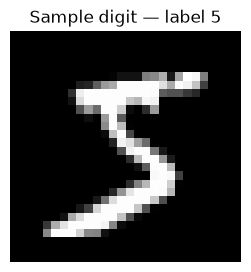

Matrix shape: (28, 28)


In [7]:
def load_sample_digit(index=0):
    """Return (image_matrix, label) for one sample digit, MNIST if available."""
    try:
        from tensorflow.keras.datasets import mnist
        (x_train, y_train), _ = mnist.load_data()
        img = x_train[index].astype(float)          # 28x28, values 0-255
        label = int(y_train[index])
        print("Loaded MNIST (28x28) via tensorflow.keras.")
        return img, label
    except Exception as e:
        print(f"TensorFlow/MNIST unavailable ({e}); falling back to sklearn's load_digits (8x8).")
        from sklearn.datasets import load_digits
        digits = load_digits()
        img = digits.images[index].astype(float)     # 8x8, values 0-16
        img = (img / img.max()) * 255.0              # rescale to 0-255 for consistency
        label = int(digits.target[index])
        return img, label


sample_img, sample_label = load_sample_digit(index=0)

plt.figure(figsize=(3, 3))
plt.imshow(sample_img, cmap='gray')
plt.title(f"Sample digit — label {sample_label}")
plt.axis('off')
plt.show()

print("Matrix shape:", sample_img.shape)

In [ ]:
# Run the convolution + animation on the MNIST sample using the same left-edge kernel.
# (If using full 28x28 MNIST this is ~26x26 = 676 steps -> the animation can take a moment
#  to build. Reduce via a crop/resize below if you want something snappier.)

# Optional: crop/resize to keep the animation shorter, e.g. sample_img[:14, :14]
mnist_anim, mnist_output = animate_convolution(
    sample_img, left_edge_kernel, stride=2, padding=1, interval=150
)

print("Output shape:", mnist_output.shape)
HTML(mnist_anim.to_jshtml())

### Try it yourself

- Swap `left_edge_kernel` for any other 3×3 (or larger) kernel — e.g. a right-edge kernel `[[-1,0,1],[-1,0,1],[-1,0,1]]`, a horizontal-edge kernel, a blur kernel `np.ones((3,3))/9`, or a sharpen kernel.
- Change `stride` and `padding` in the `animate_convolution(...)` calls above.
- Change `index` in `load_sample_digit(index=...)` to view a different MNIST digit.
- Use `image_to_matrix('your_image.png', resize=(28, 28))` to feed in your own photo instead of MNIST.